In [18]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
ROOT = Path("<LOCAL_COINGECKO_ROOT>")

OUT_DIR = Path("<LOCAL_OUTPUT_DIR>")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_DIRS = [
    ROOT / "coin_gecko",
    ROOT / "coin_gecko_20250910_112201",
    ROOT / "20260531_130117_stablecoins",
]

STABLECOINS = {
    "Tether": "tether",
    "USD Coin": "usd-coin",
    "Binance USD": "binance-usd",
    "DAI": "dai",
    "TrueUSD": "true-usd",
    "Pax Dollar": "paxos-standard",
    "Gemini Dollar": "gemini-dollar",
    "PAX Gold": "pax-gold",
    "STASIS EURO": "stasis-eurs",
    "Rupiah Token": "rupiah-token",
    "NUSD": "nusd",
}

START_DATE = "2020-01-01"

In [21]:
def read_market_cap(coin_id):
    frames = []

    for folder in SOURCE_DIRS:
        file_path = folder / f"{coin_id}.csv"

        if file_path.exists():
            df = pd.read_csv(file_path)

            df = df[["date", "market_caps"]].copy()
            df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date
            df["market_caps"] = pd.to_numeric(df["market_caps"], errors="coerce")

            df = df.dropna(subset=["date", "market_caps"])
            frames.append(df)

    if len(frames) == 0:
        raise FileNotFoundError(f"No data found for {coin_id}")

    df = pd.concat(frames, ignore_index=True)
    df = df.sort_values("date")
    df = df.drop_duplicates(subset="date", keep="last")

    return df

In [22]:
market_caps = []

for name, coin_id in STABLECOINS.items():
    df = read_market_cap(coin_id)
    df = df.rename(columns={"market_caps": name})
    market_caps.append(df.set_index("date")[name])

panel = pd.concat(market_caps, axis=1)
panel = panel.sort_index()
panel = panel[panel.index >= pd.to_datetime(START_DATE).date()]

panel = panel.ffill().fillna(0)

panel_billion = panel / 1e9

panel_billion.to_csv(OUT_DIR / "stablecoin_11_market_caps_panel.csv")

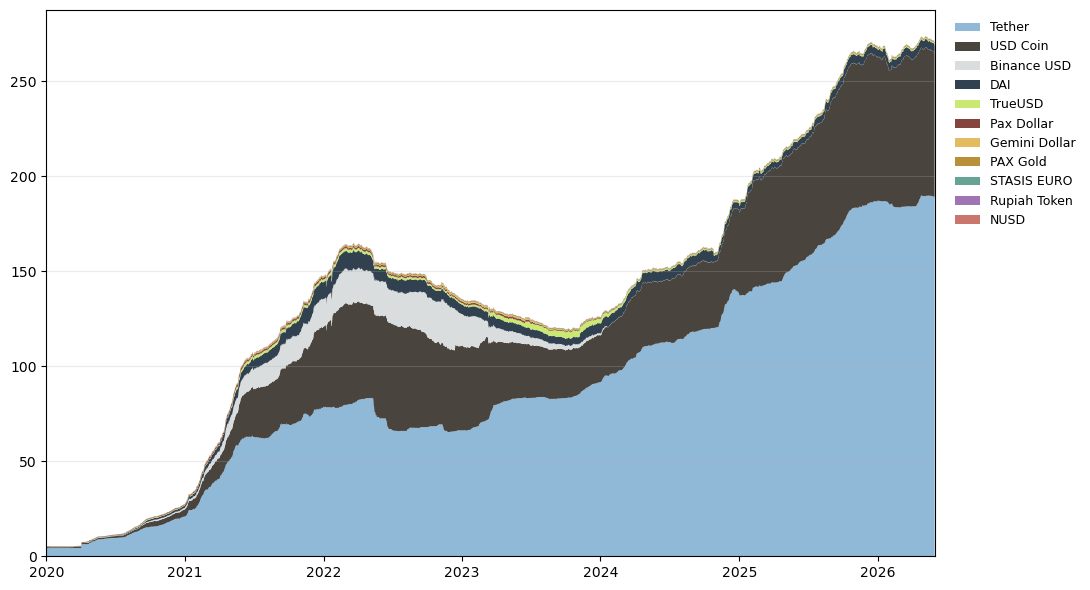

In [23]:
colors = [
    "#8ab6d6",
    "#3f3a32",
    "#d8dcdc",
    "#263746",
    "#c8e86a",
    "#7f3b32",
    "#e1b955",
    "#b68a2e",
    "#5f9e8f",
    "#9b6cae",
    "#c76f65",
]

plt.figure(figsize=(11, 6))

plt.stackplot(
    panel_billion.index,
    [panel_billion[col] for col in panel_billion.columns],
    labels=panel_billion.columns,
    colors=colors,
    alpha=0.95,
)

plt.xlim(panel_billion.index.min(), panel_billion.index.max())
plt.ylim(bottom=0)

plt.grid(axis="y", alpha=0.25)
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    frameon=False,
    fontsize=9,
)

plt.tight_layout()

plt.savefig(
    OUT_DIR / "stablecoin_11_marketcap_stacked_area.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()